# Huấn luyện U-MobileViT (dùng model thật từ `models/`)

Notebook này huấn luyện mô hình **U-MobileViT** cho bài toán **phân vùng người (person segmentation)**
trên dữ liệu COCO, **dùng trực tiếp mô hình từ `models/u_mobilevit_net/`** thay vì định nghĩa lại trong notebook.

So với `u_mobilevit_net_base.ipynb`:
- ✅ Gọi `umobilevit(...)` từ `models.u_mobilevit_net.u_models` — một nguồn sự thật duy nhất cho kiến trúc.
- ✅ Dùng **single-task head** (`head="single"`, `out_channels=1`) hợp với loss nhị phân Focal+Dice.
- ✅ Tách vòng lặp thành `train_one_epoch` / `evaluate` cho dễ đọc.
- ✅ Có **smoke test** kiểm tra model dựng & forward đúng shape trước khi nạp dữ liệu.
- ✅ Sửa lỗi tên file checkpoint khi nạp lại model tốt nhất.

**Yêu cầu**: chạy từ thư mục gốc dự án với `PYTHONPATH` trỏ vào gốc (để import được `models` và `cv_nets`).

## 1. Import thư viện

In [1]:
import os
import json
import random
import argparse

import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
import matplotlib.pyplot as plt

from models.u_mobilevit_net.u_models import umobilevit, UMobileViT

## 2. Cấu hình & siêu tham số

Các đường dẫn COCO, kích thước ảnh, batch size và tham số early-stopping. `NUM_CLASSES = 1`
vì đây là phân vùng nhị phân (người / nền) dùng hàm loss dạng sigmoid.

In [2]:
IMAGE_SIZE = (320, 320)
BATCH_SIZE = 16
NUM_WORKERS = 16
EPOCH = 100

NUM_CLASSES = 1          # phân vùng nhị phân -> 1 kênh logits + sigmoid
HEAD_TYPE = "single"     # dùng ContextAwareSegHead (1 nhánh)

TRAIN_IMG_DIR = './data/COCO/train2017'
TRAIN_ANN_FILE = './data/COCO/annotations/instances_train2017.json'
VAL_IMG_DIR = './data/COCO/val2017'
VAL_ANN_FILE = './data/COCO/annotations/instances_val2017.json'

SAVE_MODEL_DIR = './models/u_mobilevit_net'
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)

patience = 15
min_epochs_before_stop = 30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


## 3. Khởi tạo model từ `models/` + smoke test

`opts` được tạo từ `UMobileViT.add_arguments` để mọi mặc định kiến trúc (d_model, expansion_factor,
patch_size, ...) đều có sẵn. Sau đó chạy thử một tensor giả để xác nhận model dựng đúng và trả về
đúng shape `(B, NUM_CLASSES, H, W)` **trước khi** tốn công nạp dữ liệu.

In [3]:
# Tạo opts với đầy đủ tham số mặc định của kiến trúc
_parser = argparse.ArgumentParser()
UMobileViT.add_arguments(_parser)
opts, _ = _parser.parse_known_args([])

def build_model():
    return umobilevit(opts=opts, head=HEAD_TYPE, out_channels=NUM_CLASSES)

model = build_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"U-MobileViT | head={HEAD_TYPE} | out_channels={NUM_CLASSES} | params={n_params/1e6:.3f} M")

# Smoke test: forward với ảnh giả
model.eval()
with torch.no_grad():
    _dummy = torch.randn(2, 3, *IMAGE_SIZE)
    _out = model(_dummy)
assert _out.shape == (2, NUM_CLASSES, *IMAGE_SIZE), f"Shape sai: {_out.shape}"
print(f"[smoke test] OK — input {tuple(_dummy.shape)} -> output {tuple(_out.shape)}")

U-MobileViT | head=single | out_channels=1 | params=0.577 M
[smoke test] OK — input (2, 3, 320, 320) -> output (2, 1, 320, 320)


## 4. Dataset COCO (person segmentation)

`Dataset` đọc ảnh COCO, gộp mọi annotation 'person' thành một mask nhị phân, kèm augmentation
đồng bộ ảnh–mask khi train (random scale/rotate/crop/flip + color jitter & blur chỉ trên ảnh).

In [4]:
class COCOPersonDataset(Dataset):
    """Dataset COCO cho phân vùng người, có augmentation đồng bộ ảnh & mask."""
    def __init__(self, img_dir, ann_file, image_size=IMAGE_SIZE, is_train=True):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.image_size = image_size
        self.is_train = is_train
        self.person_cat_id = self.coco.getCatIds(catNms=['person'])[0]
        self.img_ids = self.coco.getImgIds(catIds=[self.person_cat_id])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')

        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[self.person_cat_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask * 255).convert('L')

        if self.is_train:
            short_edge = random.randint(min(self.image_size), int(min(self.image_size) * 1.5))
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)

            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            i, j, h, w = T.RandomCrop.get_params(image, output_size=self.image_size)
            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)

            if random.random() > 0.5:
                image = TF.hflip(image); mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)(image)
            if random.random() > 0.7:
                image = T.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))(image)
        else:
            short_edge = min(self.image_size)
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)
            image = TF.center_crop(image, self.image_size)
            mask = TF.center_crop(mask, self.image_size)

        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask_tensor = TF.to_tensor(mask)
        return image_tensor, mask_tensor

## 5. Hàm đánh giá IoU

In [5]:
def calculate_iou(preds, masks, threshold=0.5):
    """IoU cho segmentation nhị phân (logits -> sigmoid -> ngưỡng)."""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold
    intersection = (preds & masks).float().sum((1, 2, 3))
    union = (preds | masks).float().sum((1, 2, 3))
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()

## 6. Trực quan hóa dữ liệu (ảnh | ground-truth)

In [6]:
def visualize_datasets(dataloader, num_samples=8):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225])
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    shown = 0
    for images, masks in dataloader:
        for i in range(images.size(0)):
            if shown >= num_samples: break
            row, col = shown // 2, (shown % 2) * 2
            img = np.clip(inv_normalize(images[i]).permute(1, 2, 0).numpy(), 0, 1)
            axes[row, col].imshow(img); axes[row, col].set_title(f"Sample {shown+1}: Image"); axes[row, col].axis('off')
            axes[row, col+1].imshow(masks[i].squeeze().numpy(), cmap='gray')
            axes[row, col+1].set_title("Ground Truth"); axes[row, col+1].axis('off')
            shown += 1
        if shown >= num_samples: break
    plt.suptitle("Dữ liệu mẫu (Input | Ground Truth)", fontsize=16, y=0.92); plt.show()

## 7. Nạp dữ liệu train/val

Đang tải COCO Train Annotations...
loading annotations into memory...
Done (t=9.41s)
creating index...
index created!


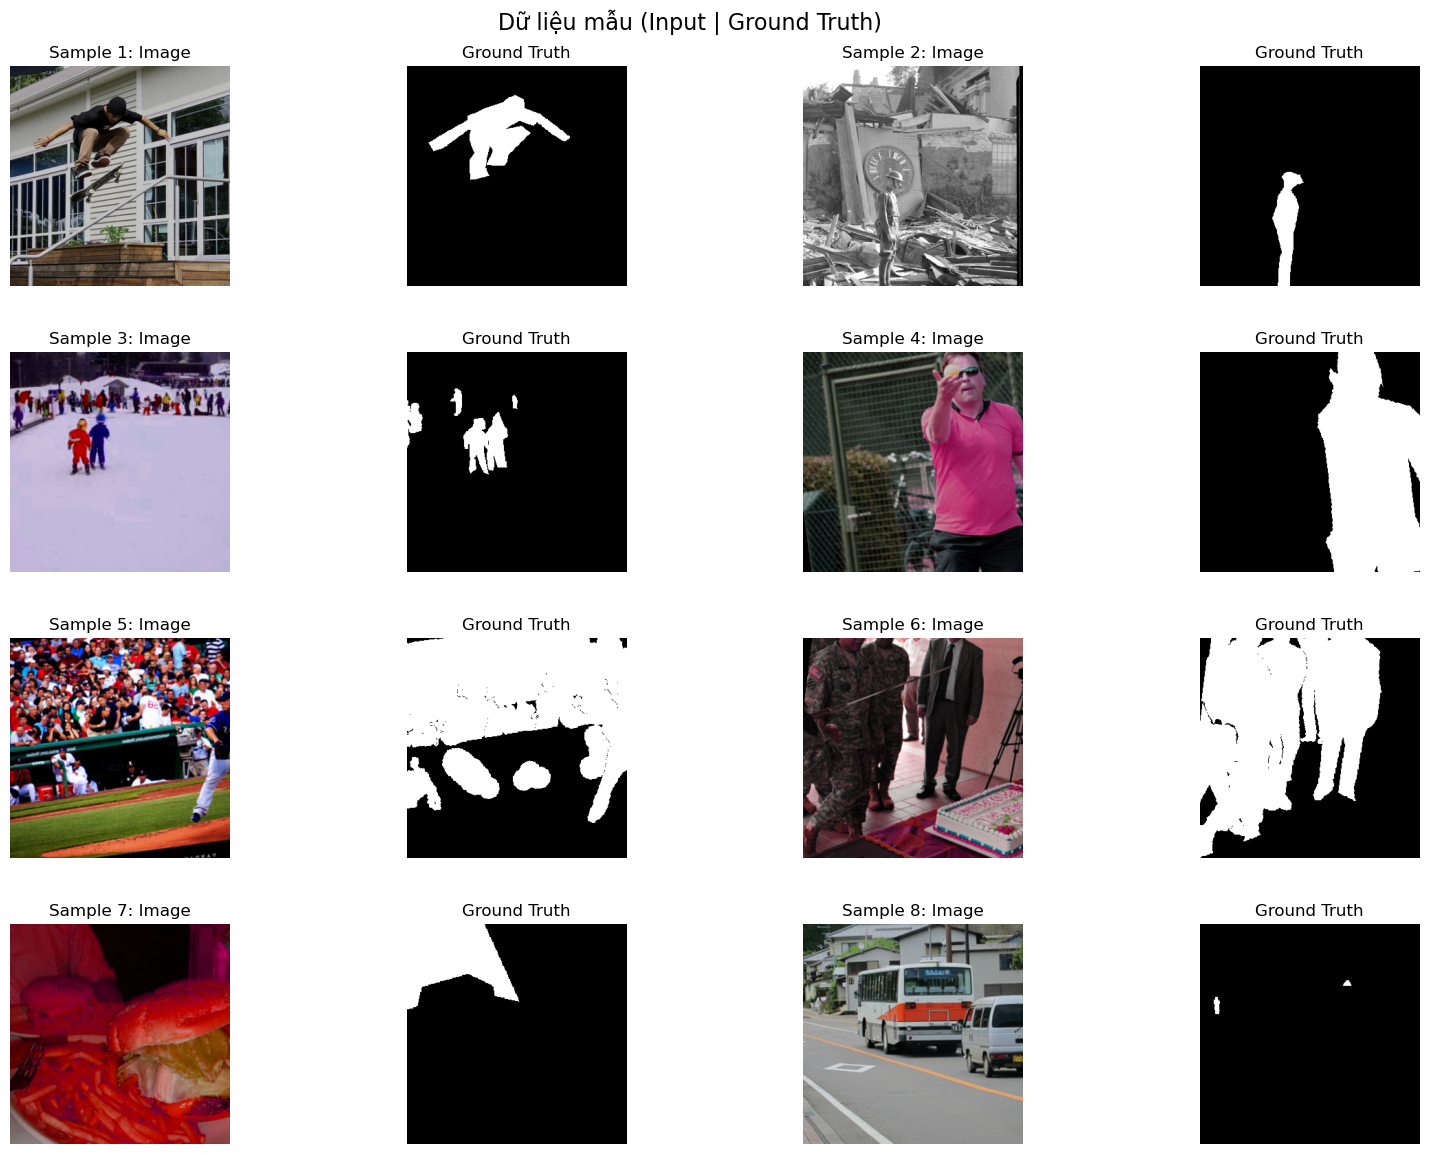

In [7]:
print("Đang tải COCO Train Annotations...")
train_dataset = COCOPersonDataset(TRAIN_IMG_DIR, TRAIN_ANN_FILE, image_size=IMAGE_SIZE, is_train=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
visualize_datasets(train_loader)

loading annotations into memory...
Done (t=1.39s)
creating index...
index created!


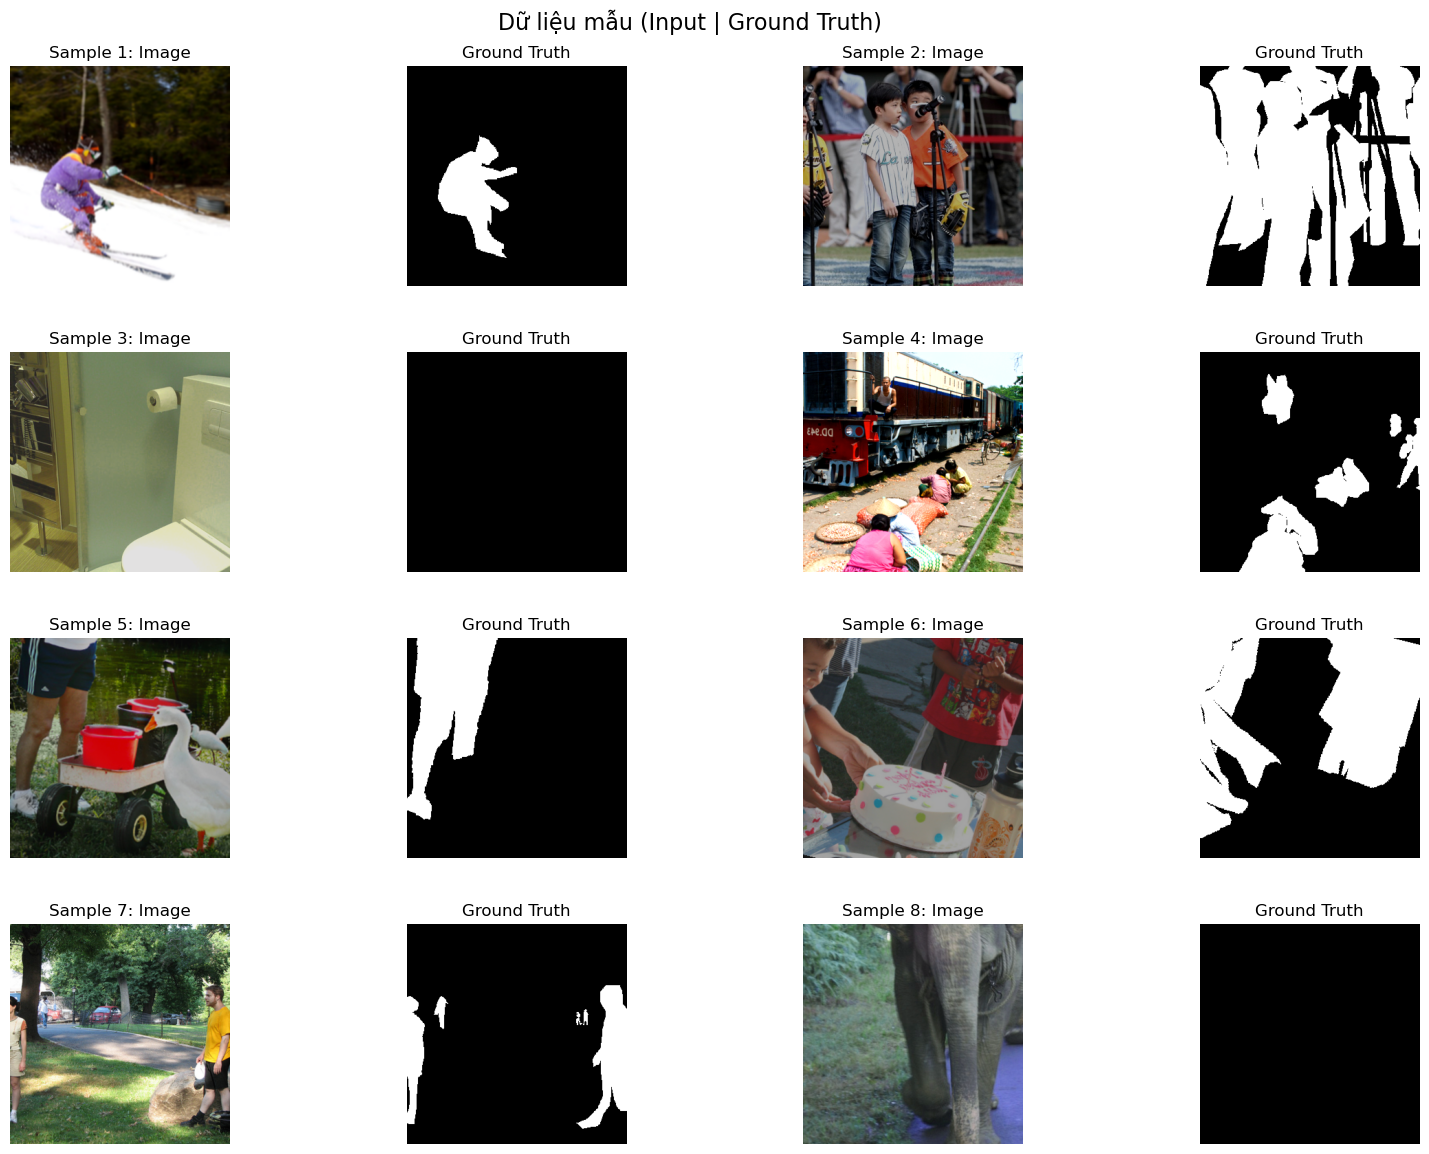

In [8]:
val_dataset = COCOPersonDataset(VAL_IMG_DIR, VAL_ANN_FILE, image_size=IMAGE_SIZE, is_train=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
visualize_datasets(train_loader)

In [9]:
print(f"Tìm thấy {len(train_dataset)} ảnh Train và {len(val_dataset)} ảnh Val chứa người.")

Tìm thấy 64115 ảnh Train và 2693 ảnh Val chứa người.


## 8. Hàm mất mát Focal + Dice

Kết hợp **Focal Loss** (tập trung pixel khó, giảm trọng số nền) và **Dice Loss** (tối ưu trực tiếp độ trùng vùng).

In [10]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, dice_weight=0.5):
        super().__init__()
        self.alpha, self.gamma, self.dice_weight = alpha, gamma, dice_weight

    def forward(self, inputs, targets, smooth=1e-6):
        # Luôn tính loss ở float32 để tránh NaN (float16 có min ~6e-5, nhỏ hơn smooth)
        inputs = inputs.float()
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        pt = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = (alpha_t * (1 - pt) ** self.gamma * bce).mean()

        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = 1.0 - ((2. * intersection + smooth) / (union + smooth)).mean()
        combined = (1 - self.dice_weight) * focal + self.dice_weight * dice
        return combined, focal.detach(), dice.detach()

## 9. Thiết lập huấn luyện

Optimizer Adam + scheduler ReduceLROnPlateau + AMP (mixed precision khi có CUDA).
Vòng lặp được tách thành hai hàm rõ ràng: `train_one_epoch` và `evaluate`.

In [11]:
model = model.to(device)

scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6)

history = {
    'train_loss': [], 'train_focal': [], 'train_dice': [],
    'val_loss': [], 'val_focal': [], 'val_dice': [], 'val_iou': [],
}
best_val_loss = float('inf')
early_stop_counter = 0


def train_one_epoch(epoch):
    model.train()
    running_loss, running_focal, running_dice = 0.0, 0.0, 0.0
    bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Train]", unit="batch")
    for images, masks in bar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
        # Tính loss ở float32 (bên ngoài autocast) để tránh NaN
        loss, focal, dice = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        running_focal += focal.item()
        running_dice += dice.item()
        bar.set_postfix(loss=f"{loss.item():.4f}", dice=f"{dice.item():.4f}")
    n = len(train_loader)
    return running_loss / n, running_focal / n, running_dice / n


@torch.no_grad()
def evaluate(epoch):
    model.eval()
    loss_sum, focal_sum, dice_sum, iou_sum = 0.0, 0.0, 0.0, 0.0
    bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Val]", unit="batch", leave=False)
    for images, masks in bar:
        images, masks = images.to(device), masks.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
        # Tính loss ở float32 (bên ngoài autocast) để tránh NaN
        loss, focal, dice = criterion(outputs, masks)
        loss_sum += loss.item()
        focal_sum += focal.item()
        dice_sum += dice.item()
        iou_sum += calculate_iou(outputs, masks)
    n = len(val_loader)
    return loss_sum / n, focal_sum / n, dice_sum / n, iou_sum / n

/tmp/ipykernel_19968/380477614.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')


## 10. Vòng lặp huấn luyện (kèm early stopping & lưu checkpoint)

In [12]:
best_path = os.path.join(SAVE_MODEL_DIR, "best_u_mobilevit_net.pth")
last_path = os.path.join(SAVE_MODEL_DIR, "last_u_mobilevit_net.pth")

for epoch in range(EPOCH):
    avg_train_loss, avg_train_focal, avg_train_dice = train_one_epoch(epoch)
    avg_val_loss, avg_val_focal, avg_val_dice, avg_val_iou = evaluate(epoch)

    history['train_loss'].append(avg_train_loss)
    history['train_focal'].append(avg_train_focal)
    history['train_dice'].append(avg_train_dice)
    history['val_loss'].append(avg_val_loss)
    history['val_focal'].append(avg_val_focal)
    history['val_dice'].append(avg_val_dice)
    history['val_iou'].append(avg_val_iou)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"-> Epoch {epoch+1:03d} | LR: {current_lr:.6f} | "
          f"Train: loss={avg_train_loss:.4f} focal={avg_train_focal:.4f} dice={avg_train_dice:.4f} | "
          f"Val: loss={avg_val_loss:.4f} focal={avg_val_focal:.4f} dice={avg_val_dice:.4f} IoU={avg_val_iou:.4f}")
    scheduler.step(avg_val_loss)

    ckpt = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss': avg_val_loss, 'val_iou': avg_val_iou, 'history': history,
    }

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        torch.save(ckpt, best_path)
        print(f"Đã cập nhật mô hình tốt nhất tại: {best_path}\n")
    else:
        print()
        if (epoch + 1) > min_epochs_before_stop:
            early_stop_counter += 1
            print(f"[Cảnh báo] Val Loss không giảm. {early_stop_counter}/{patience} (Early Stopping)")
            if early_stop_counter >= patience:
                print(f"==== EARLY STOPPING tại Epoch {epoch+1} ====")
                torch.save(ckpt, last_path)
                break

    torch.save(ckpt, last_path)

Epoch 1/100 [Train]: 100%|██████████| 4008/4008 [06:03<00:00, 11.01batch/s, dice=0.4119, loss=0.2419]


-> Epoch 001 | LR: 0.001000 | Train: loss=0.3446 focal=0.0766 dice=0.6126 | Val: loss=0.3205 focal=0.0936 dice=0.5475 IoU=0.3931
Đã cập nhật mô hình tốt nhất tại: ./models/u_mobilevit_net/best_u_mobilevit_net.pth



Epoch 2/100 [Train]: 100%|██████████| 4008/4008 [06:07<00:00, 10.90batch/s, dice=0.6740, loss=0.3603]


-> Epoch 002 | LR: 0.001000 | Train: loss=0.3140 focal=0.0738 dice=0.5542 | Val: loss=0.2918 focal=0.0709 dice=0.5127 IoU=0.4195
Đã cập nhật mô hình tốt nhất tại: ./models/u_mobilevit_net/best_u_mobilevit_net.pth



Epoch 3/100 [Train]: 100%|██████████| 4008/4008 [06:05<00:00, 10.97batch/s, dice=0.9110, loss=0.5031]


...

-> Epoch 006 | LR: 0.001000 | Train: loss=0.2837 focal=0.0695 dice=0.4979 | Val: loss=0.2683 focal=0.0698 dice=0.4668 IoU=0.4710
Đã cập nhật mô hình tốt nhất tại: ./models/u_mobilevit_net/best_u_mobilevit_net.pth



Epoch 7/100 [Train]: 100%|██████████| 4008/4008 [06:04<00:00, 11.00batch/s, dice=0.7500, loss=0.3903]


-> Epoch 007 | LR: 0.001000 | Train: loss=0.2795 focal=0.0689 dice=0.4902 | Val: loss=0.2668 focal=0.0527 dice=0.4808 IoU=0.4698
Đã cập nhật mô hình tốt nhất tại: ./models/u_mobilevit_net/best_u_mobilevit_net.pth



Epoch 8/100 [Train]:   2%|▏         | 70/4008 [00:08<08:17,  7.91batch/s, dice=0.4808, loss=0.2682] 


KeyboardInterrupt: 

## 11. Lưu & vẽ lịch sử huấn luyện

Hoàn tất! Đã xuất ./models/u_mobilevit_net/training_history.json.


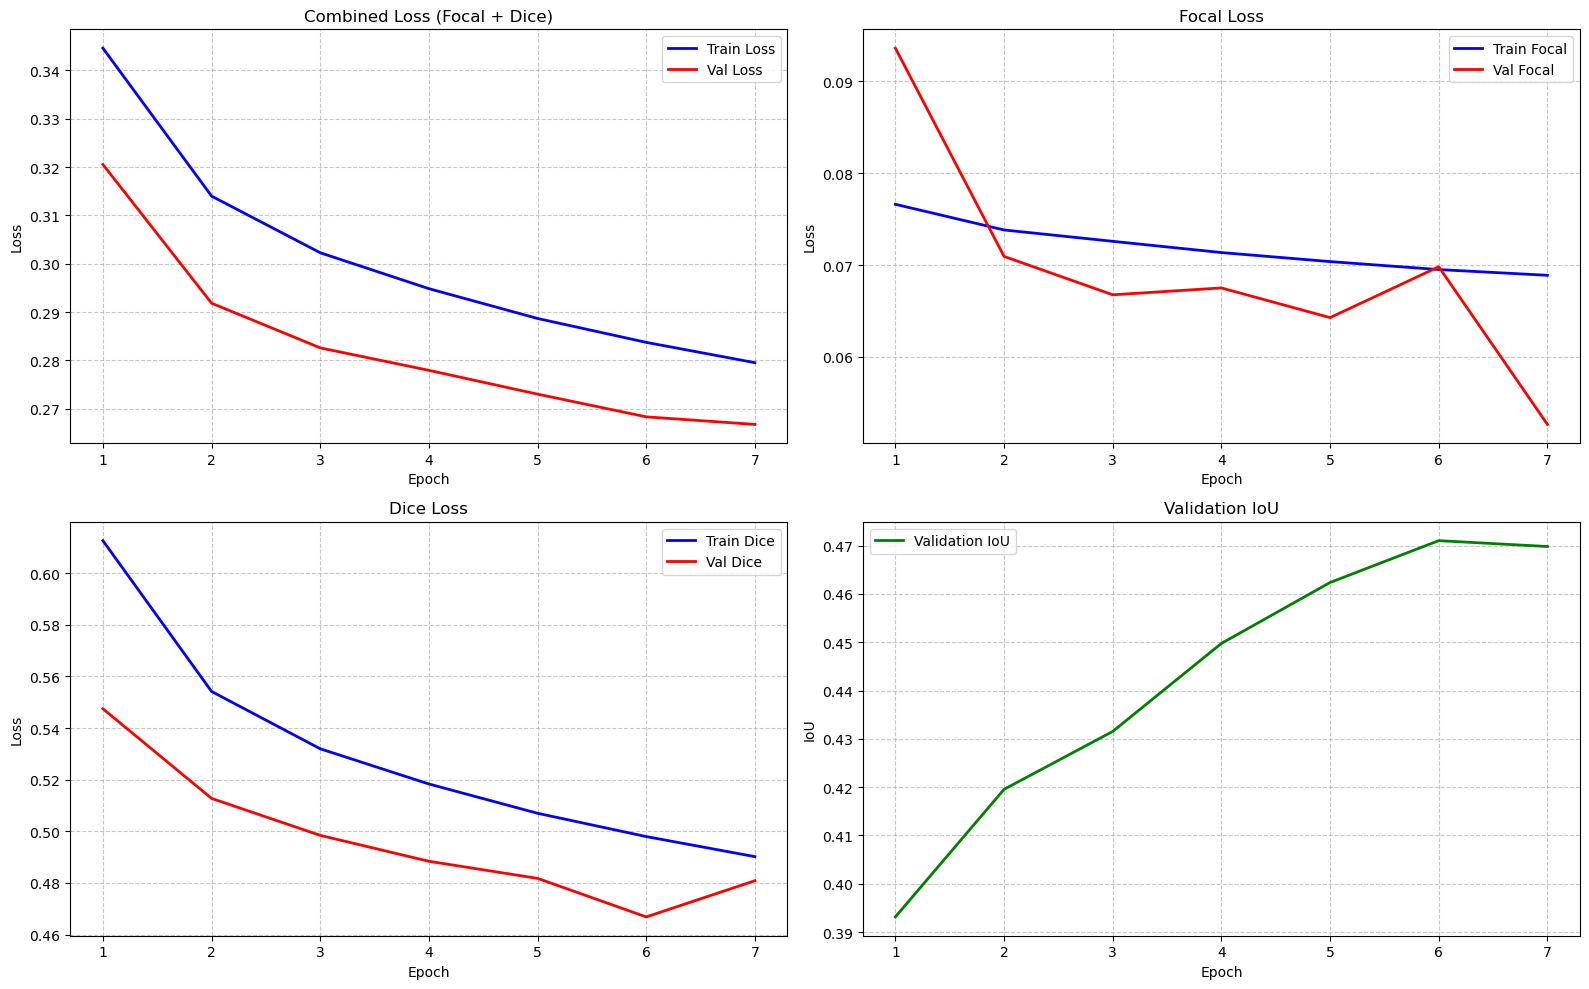

In [13]:
train_his_file = os.path.join(SAVE_MODEL_DIR, "training_history.json")
with open(train_his_file, "w") as f:
    json.dump(history, f, indent=4)
print(f"Hoàn tất! Đã xuất {train_his_file}.")


def plot_training_history(history_source):
    if isinstance(history_source, str) and os.path.exists(history_source):
        with open(history_source, "r") as f:
            hist = json.load(f)
    elif isinstance(history_source, dict):
        hist = history_source
    else:
        raise ValueError("Đầu vào phải là dict 'history' hoặc đường dẫn JSON.")

    tr, vl = hist.get('train_loss', []), hist.get('val_loss', [])
    tr_focal, vl_focal = hist.get('train_focal', []), hist.get('val_focal', [])
    tr_dice, vl_dice = hist.get('train_dice', []), hist.get('val_dice', [])
    vi = hist.get('val_iou', [])
    epochs = range(1, len(tr) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Combined Loss
    axes[0, 0].plot(epochs, tr, 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, vl, 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Combined Loss (Focal + Dice)'); axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True, ls='--', alpha=0.7)

    # Focal Loss
    axes[0, 1].plot(epochs, tr_focal, 'b-', label='Train Focal', linewidth=2)
    axes[0, 1].plot(epochs, vl_focal, 'r-', label='Val Focal', linewidth=2)
    axes[0, 1].set_title('Focal Loss'); axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend(); axes[0, 1].grid(True, ls='--', alpha=0.7)

    # Dice Loss
    axes[1, 0].plot(epochs, tr_dice, 'b-', label='Train Dice', linewidth=2)
    axes[1, 0].plot(epochs, vl_dice, 'r-', label='Val Dice', linewidth=2)
    axes[1, 0].set_title('Dice Loss'); axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend(); axes[1, 0].grid(True, ls='--', alpha=0.7)

    # Validation IoU
    axes[1, 1].plot(epochs, vi, 'g-', label='Validation IoU', linewidth=2)
    axes[1, 1].set_title('Validation IoU'); axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('IoU')
    axes[1, 1].legend(); axes[1, 1].grid(True, ls='--', alpha=0.7)

    plt.tight_layout(); plt.show()


plot_training_history(history)

## 12. Trực quan hóa dự đoán

In [15]:
def apply_color_mask(image, mask, color=(0.0, 1.0, 0.0), alpha=0.5):
    out = image.copy()
    for c in range(3):
        out[:, :, c] = np.where(mask > 0, image[:, :, c] * (1 - alpha) + alpha * color[c], image[:, :, c])
    return np.clip(out, 0, 1)


@torch.no_grad()
def visualize_predictions(model, dataloader, device, num_samples=8, colored=True):
    model.eval()
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225])
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    shown = 0
    for images, masks in dataloader:
        images = images.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).cpu()
        images, masks = images.cpu(), masks.cpu()
        for i in range(images.size(0)):
            if shown >= num_samples: break
            row, col = shown // 2, (shown % 2) * 3
            img = np.clip(inv_normalize(images[i]).permute(1, 2, 0).numpy(), 0, 1)
            gt = masks[i].squeeze().numpy()
            pr = preds[i].squeeze().numpy()
            axes[row, col].imshow(img); axes[row, col].set_title(f"Sample {shown+1}"); axes[row, col].axis('off')
            if colored:
                axes[row, col+1].imshow(apply_color_mask(img, gt, (0, 1, 0))); axes[row, col+1].set_title("Truth (Green)")
                axes[row, col+2].imshow(apply_color_mask(img, pr, (1, 0, 0))); axes[row, col+2].set_title("Pred (Red)")
            else:
                axes[row, col+1].imshow(gt, cmap='gray'); axes[row, col+1].set_title("Ground Truth")
                axes[row, col+2].imshow(pr, cmap='gray'); axes[row, col+2].set_title("Prediction")
            for k in (1, 2): axes[row, col+k].axis('off')
            shown += 1
        if shown >= num_samples: break
    plt.suptitle("Đánh giá U-MobileViT (Input | Ground Truth | Prediction)", fontsize=16, y=0.92); plt.show()

## 13. Nạp model tốt nhất & đánh giá cuối

Nạp checkpoint **`best_u_mobilevit_net.pth`** (đúng tên đã lưu ở bước huấn luyện) và trực quan hóa
trên tập validation và train.

In [16]:
best_path = os.path.join(SAVE_MODEL_DIR, "best_u_mobilevit_net.pth")
best_ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f"Đã nạp model tốt nhất (epoch {best_ckpt.get('epoch')}, val_iou={best_ckpt.get('val_iou'):.4f})")





Đã nạp model tốt nhất (epoch 7, val_iou=0.4698)


/tmp/ipykernel_19968/619233619.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt = torch.load(best_path, map_location=device)



Kết quả trên tập Train:


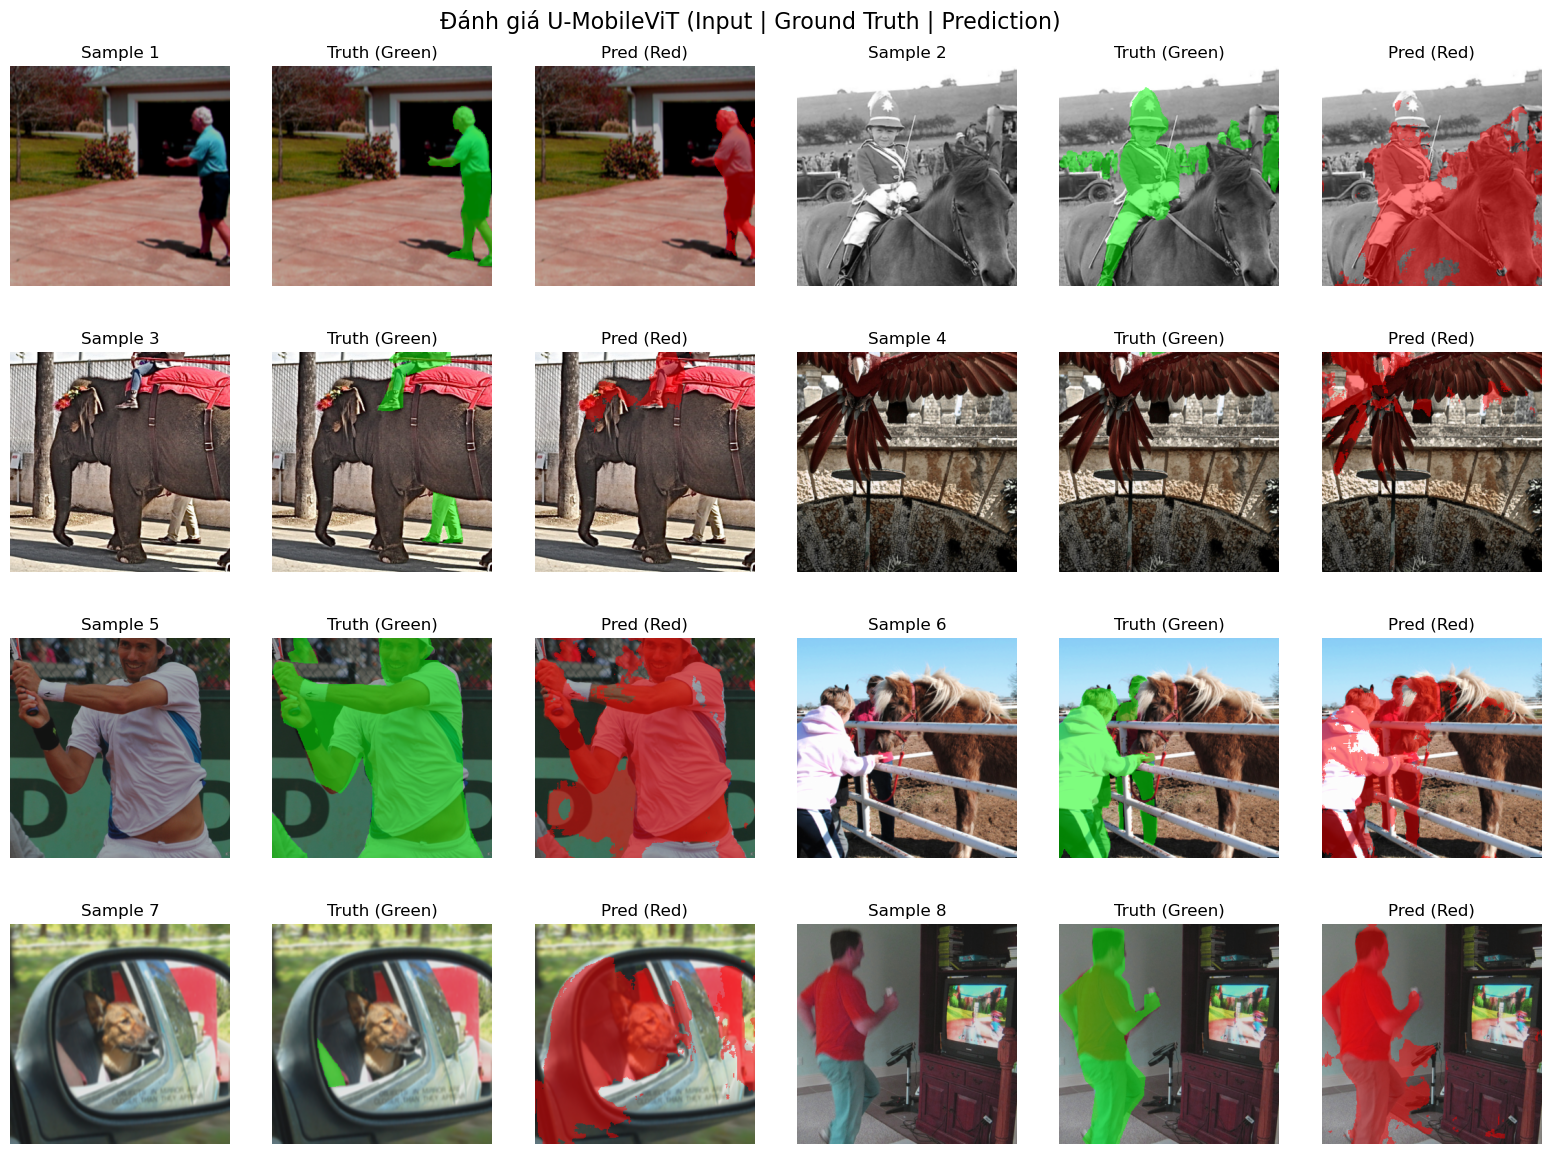

In [17]:
print("\nKết quả trên tập Train:")
visualize_predictions(model, train_loader, device, num_samples=8, colored=True)


Kết quả trên tập Validation:


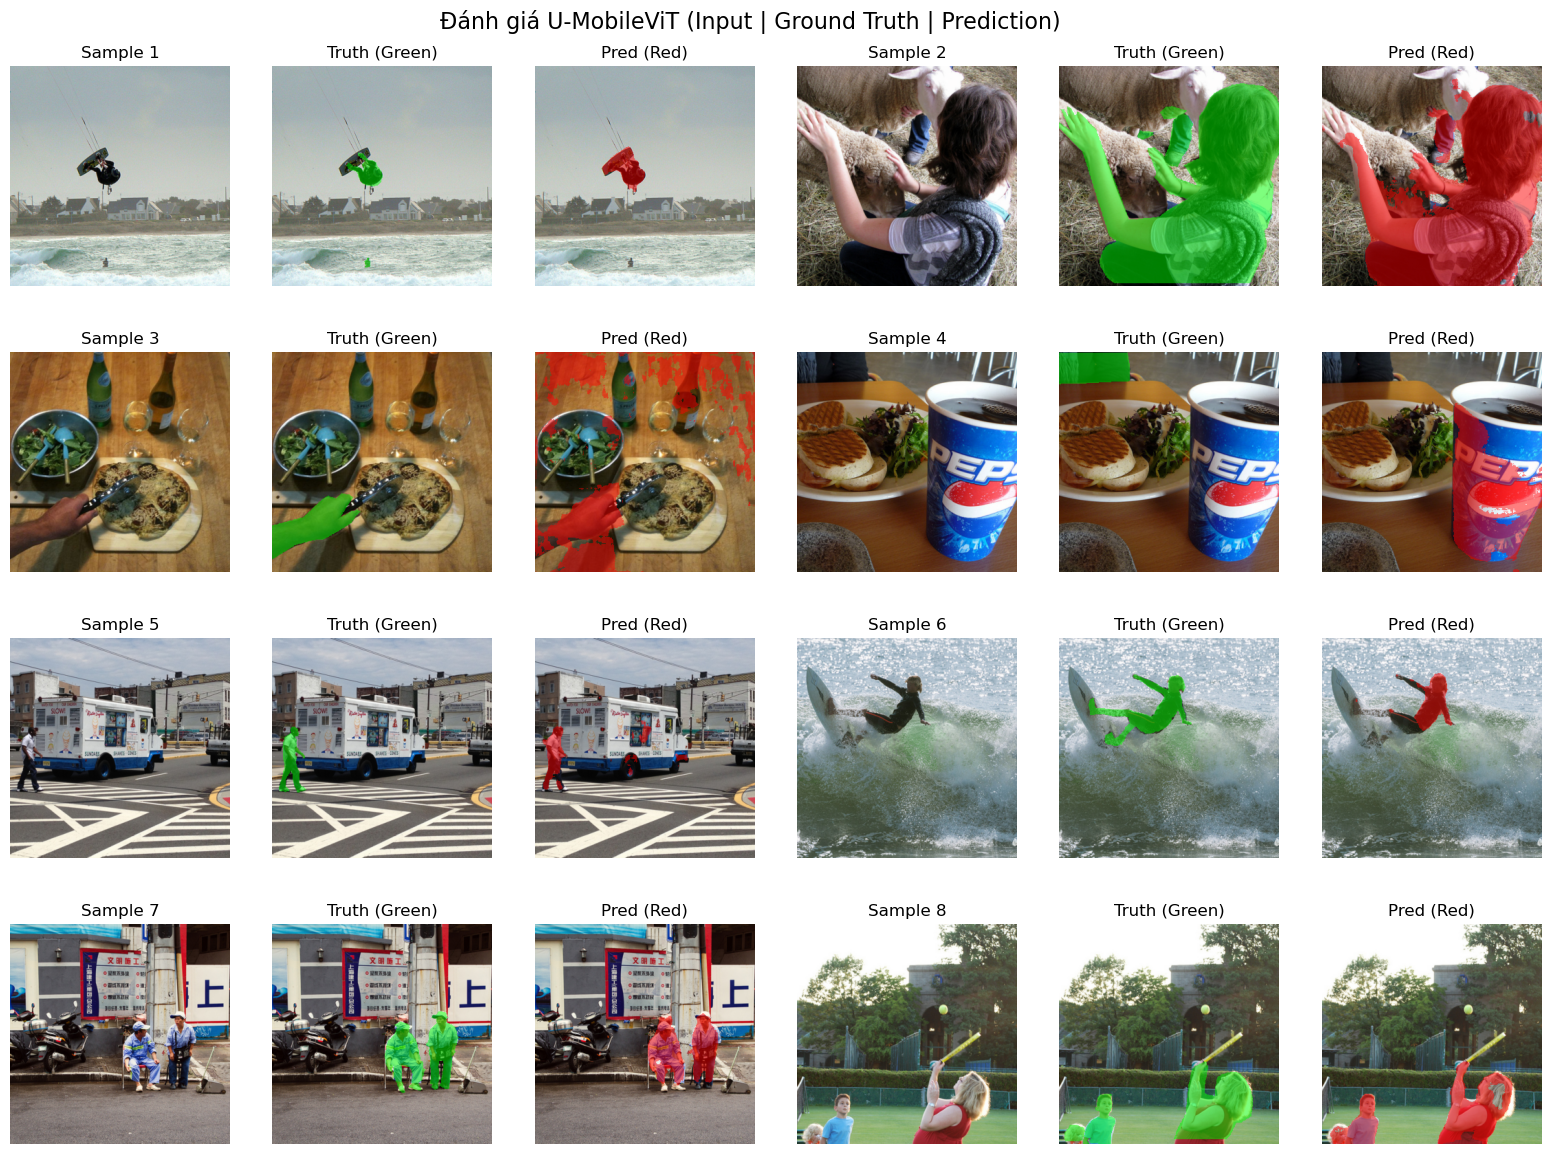

In [18]:
print("\nKết quả trên tập Validation:")
visualize_predictions(model, val_loader, device, num_samples=8, colored=True)